In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [17]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")
txn = pd.read_csv("../data/processed/transactions_cleaned.csv")
perf = pd.read_csv("../data/processed/performance_cleaned.csv")

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
print("NAV Columns:")
print(nav.columns)

print("\nTransactions Columns:")
print(txn.columns)

print("\nPerformance Columns:")
print(perf.columns)

NAV Columns:
Index(['amfi_code', 'date', 'nav'], dtype='str')

Transactions Columns:
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

Performance Columns:
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [4]:
import plotly.express as px

# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Plot NAV trend
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis (2022-2026)"
)

fig.show()

Insight 1:
Most mutual fund schemes show a steady upward NAV trend from 2022 to 2026, indicating long-term growth and positive fund performance.

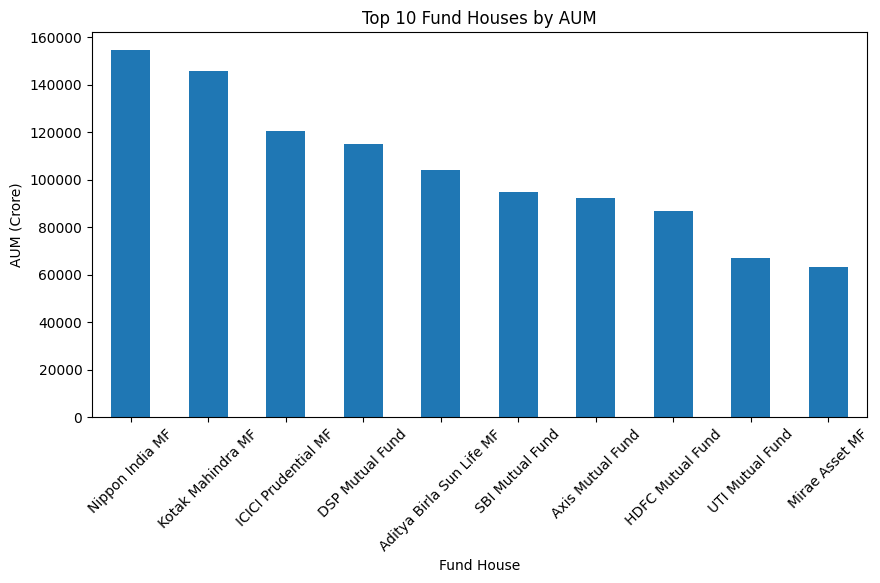

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 fund houses by AUM
top_funds = (
    perf.groupby("fund_house")["aum_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_funds.plot(kind="bar")
plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)
plt.show()

Insight 2:
A few major fund houses contribute a significant share of total AUM, indicating market concentration among leading asset management companies.

In [6]:
# Convert date column
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

# Filter SIP transactions
sip_data = txn[txn["transaction_type"] == "SIP"]

# Monthly SIP amount
monthly_sip = (
    sip_data.groupby(sip_data["transaction_date"].dt.to_period("M"))["amount_inr"]
    .sum()
    .reset_index()
)

monthly_sip["transaction_date"] = monthly_sip["transaction_date"].astype(str)

import plotly.express as px

fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    title="Monthly SIP Inflow Trend"
)

fig.show()

Insight 3:
Monthly SIP inflows show a generally increasing trend, reflecting growing investor participation in mutual funds.

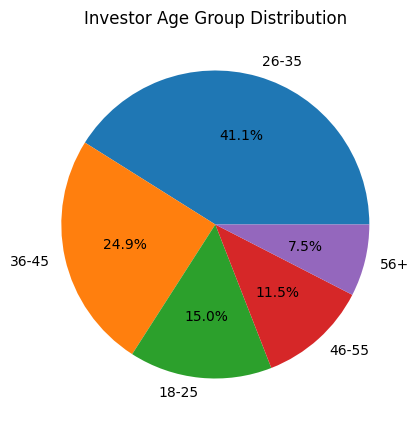

In [7]:
plt.figure(figsize=(8,5))

txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")
plt.ylabel("")
plt.show()

Insight 4:
The majority of investors belong to a few key age groups, indicating concentrated participation among working-age individuals.

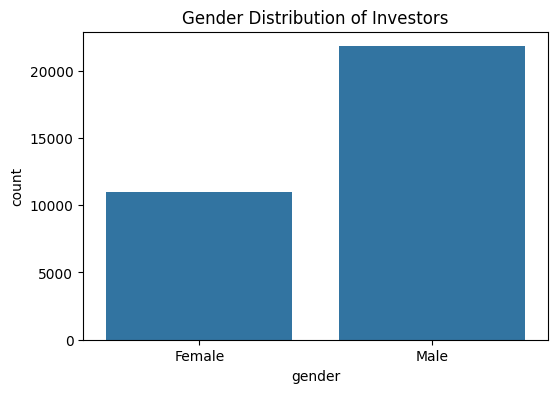

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(data=txn, x="gender")

plt.title("Gender Distribution of Investors")
plt.show()

Insight 5:
Investor participation differs across gender groups, providing useful demographic insights.

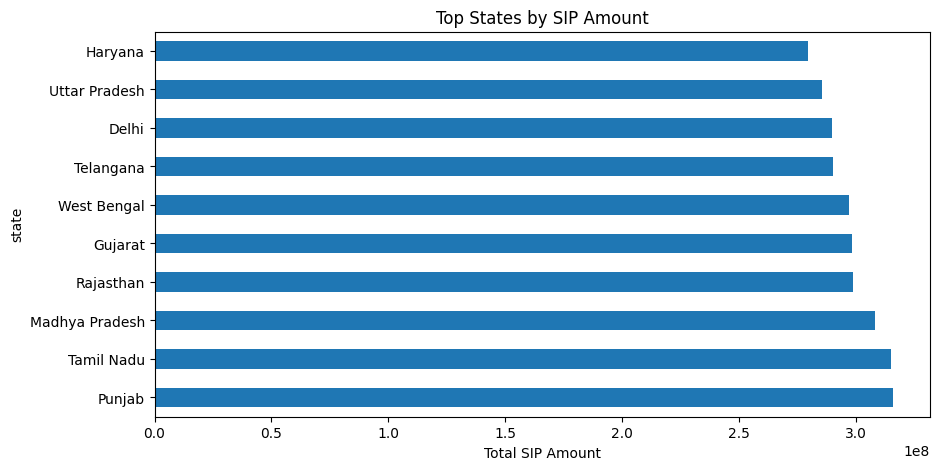

In [9]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

state_sip.plot(kind="barh")

plt.title("Top States by SIP Amount")
plt.xlabel("Total SIP Amount")
plt.show()

Insight 6:
A small number of states contribute a large portion of total SIP investments.

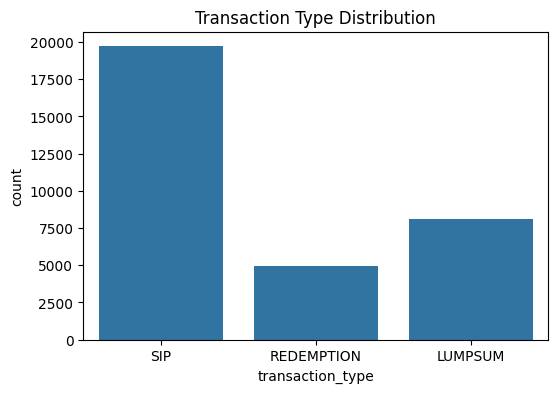

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=txn, x="transaction_type")

plt.title("Transaction Type Distribution")

plt.show()

Insight 7:
SIP transactions account for a major share of overall investment activity.

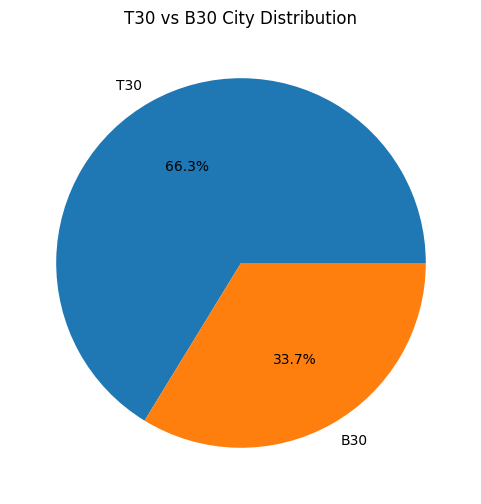

In [14]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("T30 vs B30 City Distribution")
plt.ylabel("")

plt.show()

Insight 8:
Investments are distributed across both T30 and B30 cities, showing growing penetration beyond major metros.

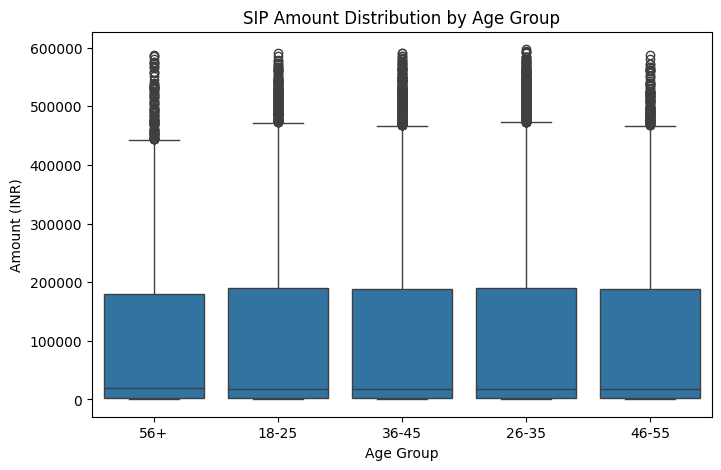

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(data=txn, x="age_group", y="amount_inr")

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

Insight 9:
Investment amounts vary across age groups, with some age groups showing higher median SIP contributions.

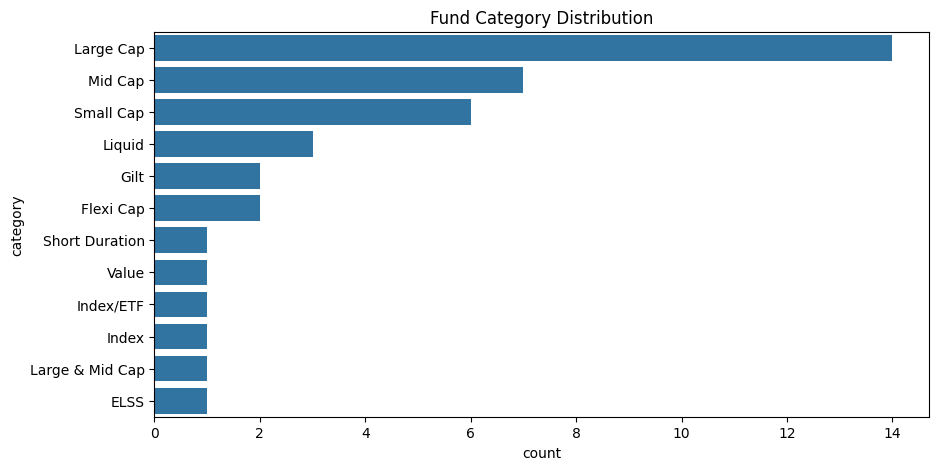

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(data=perf, y="category",
              order=perf["category"].value_counts().index)

plt.title("Fund Category Distribution")

plt.show()

Insight 10:
Certain fund categories dominate the mutual fund universe, indicating investor preference for specific investment styles.

In [18]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'HDFC_Top100_live_nav.csv']


In [19]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("CATEGORY FILE")
print(cat.columns)

print("\nFOLIO FILE")
print(folio.columns)

print("\nHOLDINGS FILE")
print(holdings.columns)

CATEGORY FILE
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

FOLIO FILE
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

HOLDINGS FILE
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


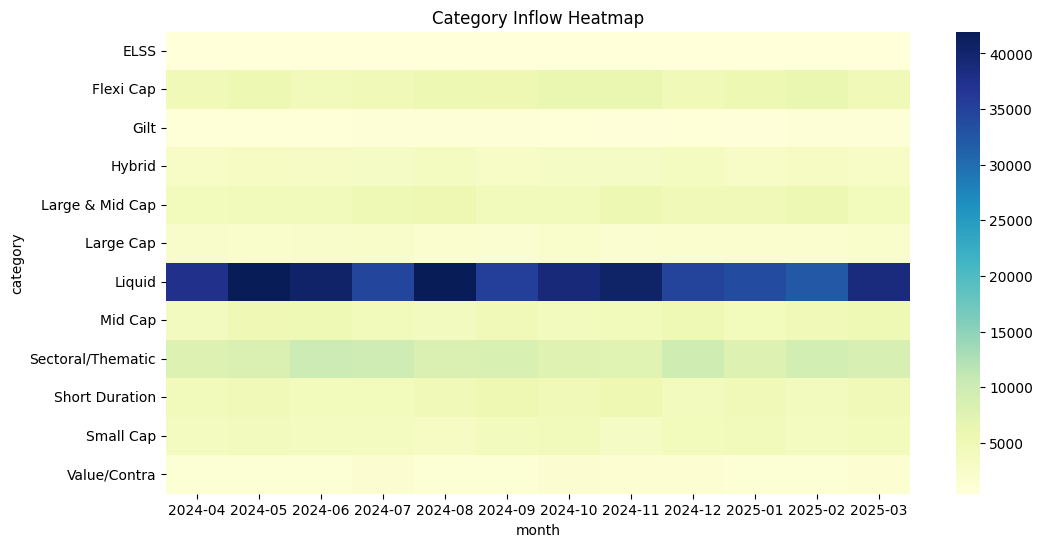

In [20]:
cat = pd.read_csv("../data/raw/05_category_inflows.csv")

heatmap_data = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data, cmap="YlGnBu")

plt.title("Category Inflow Heatmap")

plt.show()

Insight 11:
Certain fund categories consistently attract higher inflows than others, indicating stronger investor preference.

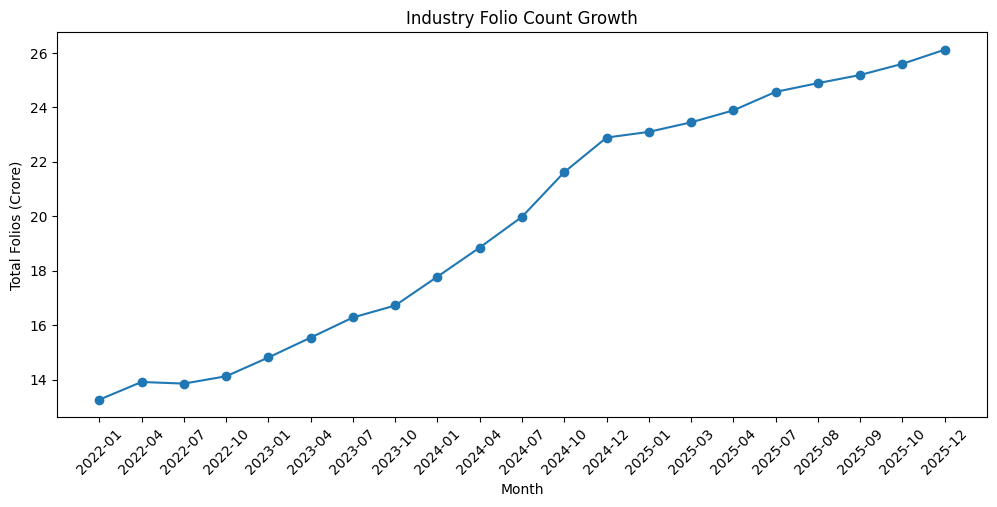

In [21]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.show()

Insight 12:
Industry folio counts show strong growth over time, indicating increasing retail participation in mutual funds.

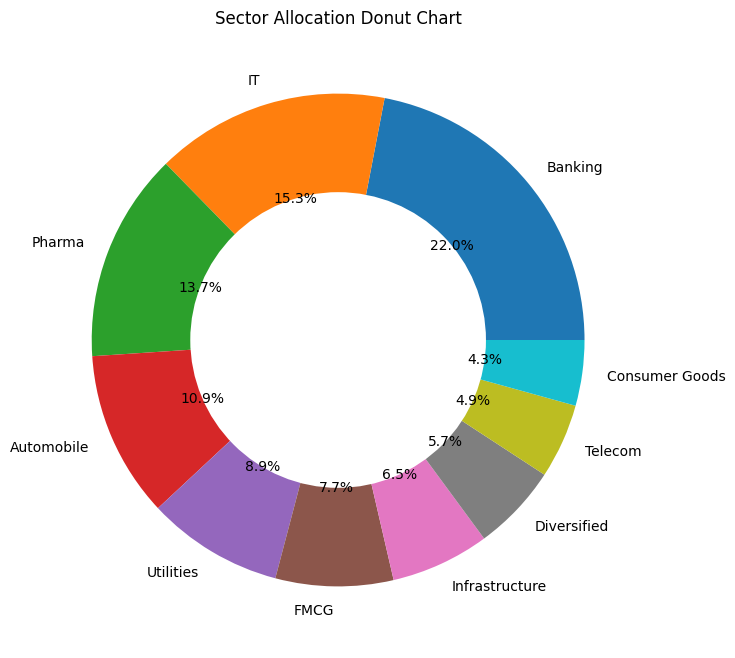

In [22]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

sector_data = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Donut Chart")

plt.show()

Insight 13:
Portfolio allocations are concentrated in a few sectors, highlighting sectoral preferences among equity funds.

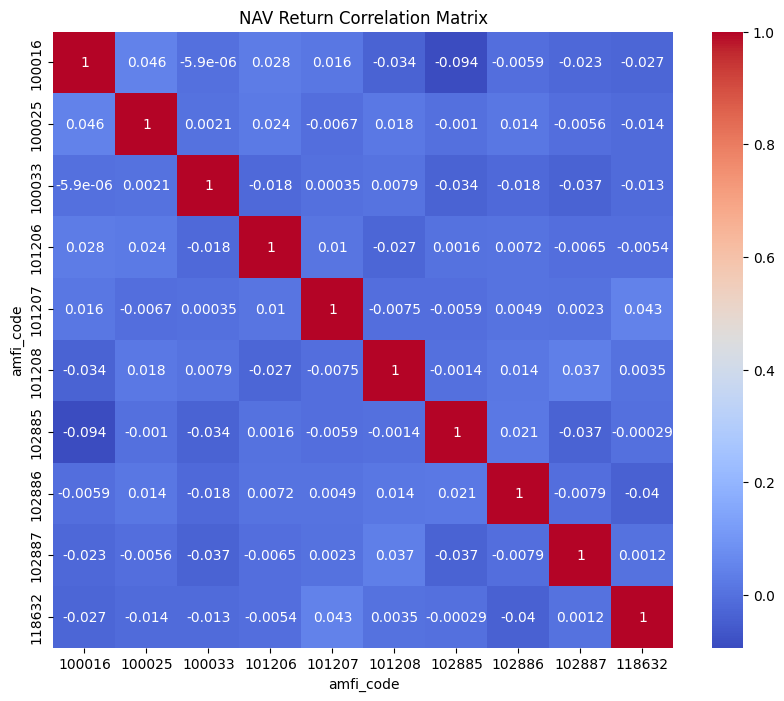

In [23]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

top_funds = nav["amfi_code"].unique()[:10]

nav_10 = nav[nav["amfi_code"].isin(top_funds)]

pivot_nav = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

Insight 14:
Several funds exhibit strong positive correlations, suggesting similar market exposure and investment strategies.

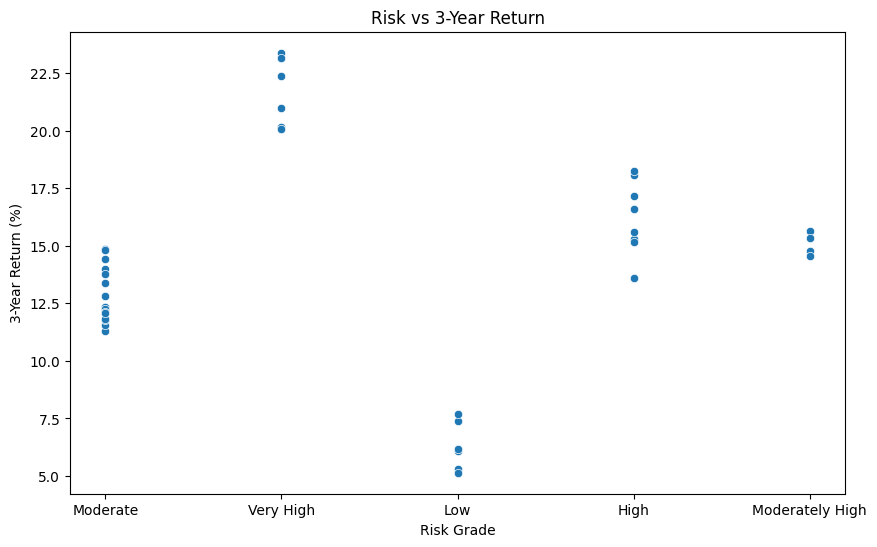

In [24]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=perf,
    x="risk_grade",
    y="return_3yr_pct"
)

plt.title("Risk vs 3-Year Return")

plt.xlabel("Risk Grade")
plt.ylabel("3-Year Return (%)")

plt.show()

Insight 15:
Higher-risk funds generally tend to deliver higher long-term returns, though exceptions exist.